<h1 align="center">CAMM Hackathon - Session 1</h1>
<p align="left"><em>26 September 2025</em></p>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/KBForgeX/camm_hackathon/blob/k4my4r/docs/regressors/CAMM_Hackathon_1.ipynb)




**Data provenance** : The dataset aggregates measurements from a Dy–Er–Gd–Ho oxide wafer study in the CAMM by the Rack and Page groups


<h3>Goal: Feature → Target Prediction</h3>


This notebook hands you a **clean, standardized dataset** and a minimal prep pipeline so you can build your own predictive models. Your goal is to use the provided **features** (materials/structure descriptors) to **predict a target property** (default: *Thermal Conductivity*). The notebook **stops at data preparation**—you will implement and compare models (e.g., linear models, trees, neural nets) using the prepared data.

**What you’ll find here**
- A tidy table with `x`, `y` wafer coordinates and a set of engineered features (numeric, aligned to the same grid, with units harmonized).
- A simple example showing how to **select a target and features**, coerce to numeric, handle missing values (median imputation), and standardize inputs—ready for modeling.
- You can swap the target and feature lists to explore different prediction tasks.

**What you will do**
- Choose a **target** (e.g., `Thermal Conductivity`) and a subset of **features** you think are predictive.
- Train any models you like (sklearn, PyTorch, etc.) on the **prepared arrays**.
- Report basic metrics (RMSE, MAE, $R^2$) and, if useful, visualize predictions on the wafer grid using `x`, `y`.


#Data Preparation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
!gdown --fuzzy https://drive.google.com/file/d/1BSZ3YyTw6dqELnL9qpfV8V5wVrbA-BPz/view?usp=sharing

Downloading...
From: https://drive.google.com/uc?id=1BSZ3YyTw6dqELnL9qpfV8V5wVrbA-BPz
To: /content/ReZrO_data.csv
100% 513k/513k [00:00<00:00, 74.5MB/s]


In [ ]:
path = "/content/ReZrO_data.csv"   # update if path differs
df = pd.read_csv(path)

Let's see what all properties we have in the dataset

In [ ]:
print("Dataframe shape:", df.shape)
display(df.head())


Dataframe shape: (2601, 17)


,x,y,Thermal Conductivity,Lattice Parameter(WPF),delta_d(SPF-WPF),d-spacing(WPF),Fluorite Size Disorder,Entropy,strain(LMFIT-dspacing),a111(LMFIT),a200(LMFIT),mismatch(LMFIT-lattice parameter),d111(LMFIT),d200(LMFIT),corr_length,fwhm111(LMFIT),delta_d/d
0,-2.5,-2.5,0.668247,5.245110,0.020399,2.622555,0.103832,3.924187,0.127131,5.245331,5.286782,-0.007902,3.028393,2.643391,2.94866,0.097076,0.007778
1,-2.5,-2.4,0.651635,5.245110,0.020399,2.622555,0.103727,3.927794,0.127131,5.245331,5.286782,-0.007902,3.028393,2.643391,2.94866,0.097076,0.007778
2,-2.5,-2.3,0.661063,5.244901,0.019877,2.622450,0.103588,3.939862,0.127240,5.245438,5.286226,-0.007776,3.028455,2.643113,2.94866,0.096367,0.007580
3,-2.5,-2.2,0.594712,5.244901,0.019877,2.622450,0.103447,3.951859,0.127240,5.245438,5.286226,-0.007776,3.028455,2.643113,2.94866,0.096367,0.007580
4,-2.5,-2.1,0.620809,5.244680,0.019664,2.622340,0.103338,3.955091,0.127249,5.245217,5.285954,-0.007766,3.028328,2.642977,2.94866,0.095942,0.007499


Let's plot them and see how they look

### Feature Definitions

1. **Lattice Parameter (WPF)**  
   Calculated by fitting the **whole XRD spectrum** using **TOPAS**.

2. **d-spacing (WPF)**  
   Average d-spacing calculated from fitting all peaks.

3. **Δd (SPF–WPF)**  
   Difference between *d-spacing (200 peak)* (2nd XRD peak) and *d-spacing (WPF)*:  
   $$ \Delta d = d_{WPF} - d_{\text{SPF}} $$

4. **delta_d/d**  
   Strain calculated from (2) and (3):  
   $$ \frac{\Delta d}{d} = \frac{d_{WPF} - d_{\text{SPF}}}{d_{\text{WPF}}} $$

5. **a111 (LMFit)**  
   Lattice parameter from fitting the **111 peak** (1st XRD peak) using the **LMFit** package.

6. **a200 (LMFit)**  
   Lattice parameter from fitting the **200 peak** (2nd XRD peak) using **LMFit**.

7. **Mismatch (LMFit – lattice parameter)**  
   $$ \text{Mismatch} = \frac{a_{111} - a_{200}}{a_{111}} $$

8. **d111 (LMFit)**  
   d-spacing of the 111 peak from LMFit.

9. **d200 (LMFit)**  
   d-spacing of the 200 peak from LMFit.

10. **Correlation Length**  
    Calculated from AFM images.

11. **FWHM111 (LMFit)**  
    Full Width at Half Maximum of the **111 peak**.

12. **Strain (LMFit – d-spacing)**  
    Strain calculated using LMFit d-spacing values:  
    $$ \frac{\Delta d}{d}{LMFIT} = \frac{d_{111} - d_{200}}{d_{111}} $$


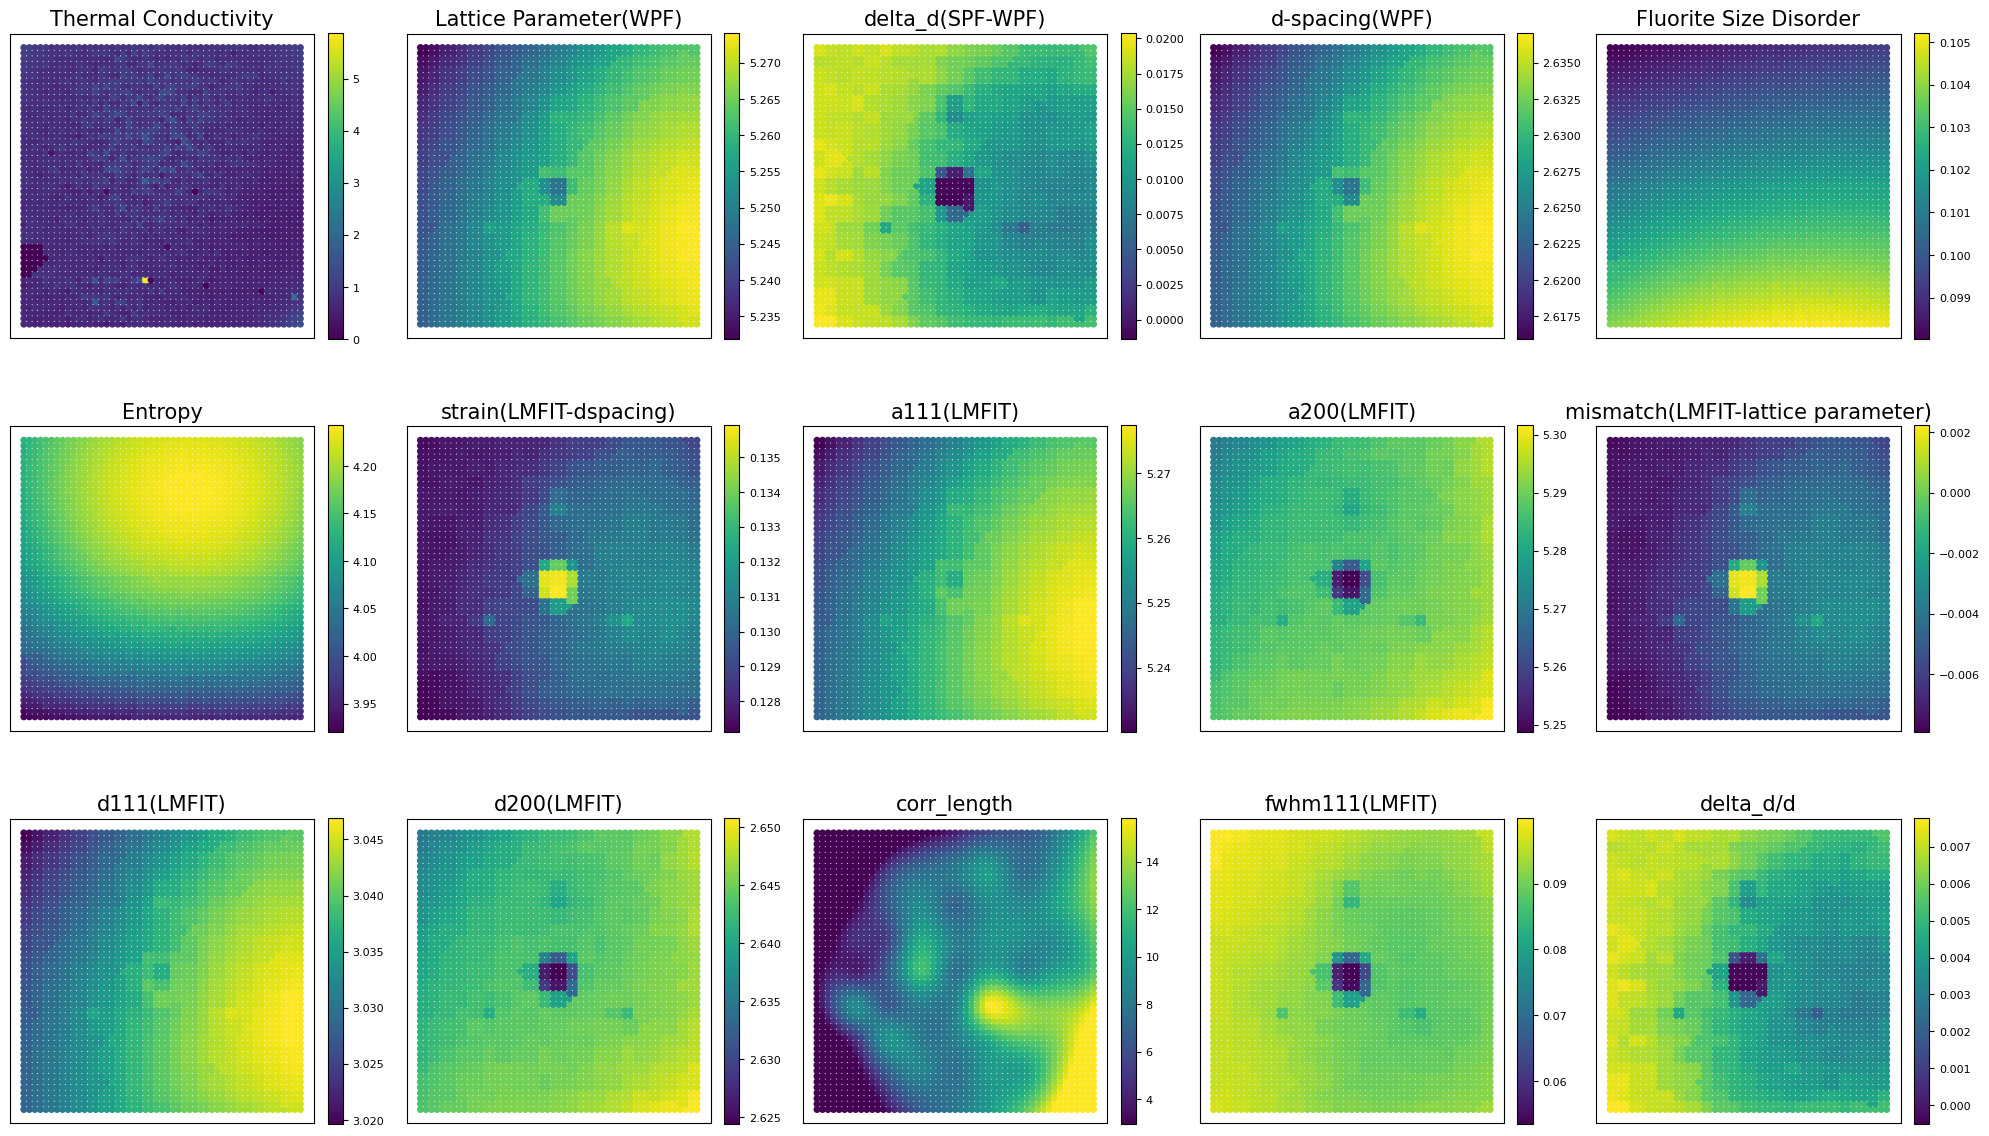

In [ ]:
x = df["x"].to_numpy()
y = df["y"].to_numpy()

feature_cols = [c for c in df.columns if c not in ["x", "y"]]

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for ax, col in zip(axes, feature_cols):
    z = pd.to_numeric(df[col], errors="coerce").to_numpy()
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)

    sc = ax.scatter(x[mask], y[mask], c=z[mask], s=16, cmap="viridis")
    ax.set_title(col, fontsize=15)
    ax.set_aspect("equal", "box")
    ax.set_xticks([]); ax.set_yticks([])

    # colorbar for each subplot
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)

# Hide any unused subplots
for ax in axes[len(feature_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# How to use this to train in networks?

In [ ]:
features = [
    'a111(LMFIT)', 'mismatch(LMFIT-lattice parameter)',
    'Fluorite Size Disorder', 'Entropy',
    'corr_length',
]
target = 'Thermal Conductivity'

missing = [c for c in features + [target] if c not in df.columns]
if missing:
    raise KeyError(f"These columns are missing in df: {missing}")

In [ ]:
for c in features + [target]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 3) drop rows with missing target
df_clean = df.dropna(subset=[target]).copy()

# 4) build matrices
X_raw = df_clean[features].to_numpy(dtype=np.float32) # Input features
y_raw = df_clean[target].to_numpy(dtype=np.float32)[:, None] #Target feature that needs to be predicted
XY    = df_clean[["x","y"]].to_numpy(dtype=np.float32) if set(["x","y"]).issubset(df_clean.columns) else None # can be used to plot predictions back on the grid


In [ ]:
X_train_raw, X_val_raw, y_train, y_val, XY_train, XY_val = train_test_split(
    X_raw, y_raw, XY, test_size=0.2, random_state=42
)
# Use this to split into training and testing dataset

We split the dataset into training and test sets because we want to test our model on unseen data

## Build your network now

Make use of Chatgpt and build your own network to predict one of the features you select